# 1) In-domain experiment
Includes **in-domain test**: sentences, that resemble the domain data

**pipeline** = HuggingFace function/task that wraps everything needed (tokenizer + model + post-processing) into one simple object. stored as **classifier**

In [14]:
!pip install transformers torch plotly pandas
from transformers import pipeline
import plotly.express as px
import pandas as pd

In [12]:
classifier = pipeline("sentiment-analysis",
                      model="distilbert-base-uncased-finetuned-sst-2-english")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [37]:
test_sentences = [
    "The story was very predictible, thus I did not enjoy it!",
    "Majority of the characters were men, which just does not interests me.",
    "Overall, the movie is good, but not my cup of tea.",
    "I saw the movie just because Mads Mikkelsen plays the main character.",
    "I saw the movie just because Cillian Murphy plays the main character.",
    "I saw the movie just because Emily Blunt plays the main character.",
    "The story is very touching, I cried, of happiness and sadness at the same time.",
    "There might never be a better story than this.",
    "It's been a while since I saw such an enjoyable piece of art."
]

for sentence in test_sentences:
    result = classifier(sentence)[0]
    print(f"{result['label']} ({result['score']:.2f}) | {sentence}")

NEGATIVE (1.00) | The story was very predictible, thus I did not enjoy it!
NEGATIVE (1.00) | Majority of the characters were men, which just does not interests me.
POSITIVE (1.00) | Overall, the movie is good, but not my cup of tea.
NEGATIVE (0.68) | I saw the movie just because Mads Mikkelsen plays the main character.
POSITIVE (0.53) | I saw the movie just because Cillian Murphy plays the main character.
POSITIVE (0.52) | I saw the movie just because Emily Blunt plays the main character.
POSITIVE (1.00) | The story is very touching, I cried, of happiness and sadness at the same time.
NEGATIVE (1.00) | There might never be a better story than this.
POSITIVE (1.00) | It's been a while since I saw such an enjoyable piece of art.


plotly dataset **gapminder()**: table of world development data -->

In [15]:
# columns: country, iso_alpha
country_df = px.data.gapminder()[["country", "iso_alpha"]].drop_duplicates().reset_index(drop=True)
#country_df.head()

adding **positive_score** for each country -->

In [16]:
def run_sentiment_query(query, country_df):
    # runs sentiment pipeline for a query template over all countries
    results = []
    for _, row in country_df.iterrows():
        sentence = query.replace("{country}", row["country"])
        output = classifier(sentence)[0]
        score = output["score"] if output["label"] == "POSITIVE" else 1 - output["score"]
        results.append({
            "country": row["country"],
            "iso_alpha": row["iso_alpha"],
            "positive_score": score
        })
    return pd.DataFrame(results)


def plot_choropleth(df, title):
    # plot a world map choropleth of positive sentiment scores
    fig = px.choropleth(
        df,
        locations="iso_alpha",
        color="positive_score",
        hover_name="country",
        color_continuous_scale="RdYlGn",
        range_color=[0, 1],
        title=title
    )
    fig.show()

# 2) Out-of-domain experiment
world map

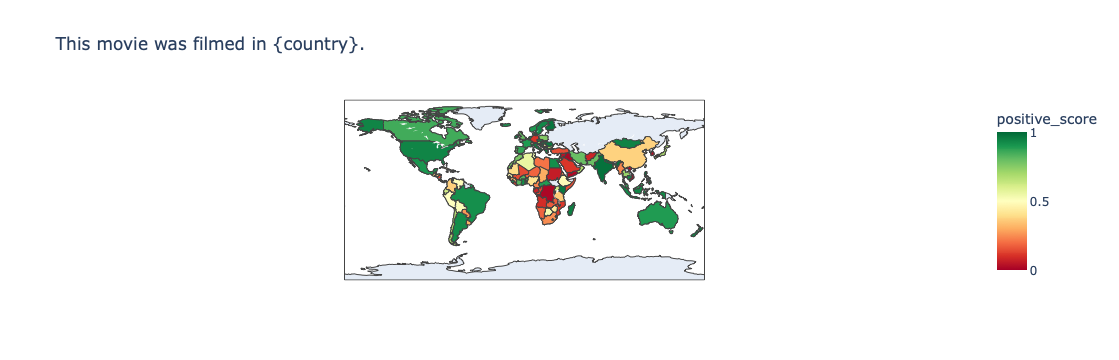

In [17]:
df_g2 = run_sentiment_query("This movie was filmed in {country}.", country_df)
plot_choropleth(df_g2, "This movie was filmed in {country}.")

# 3) Custom queries

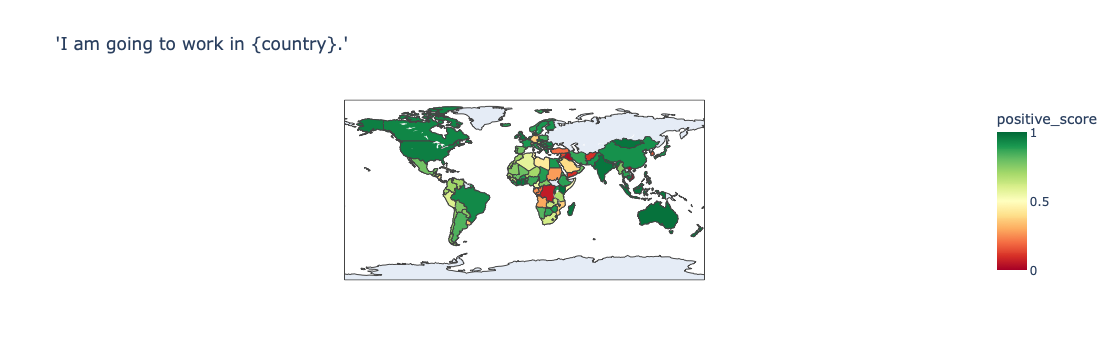

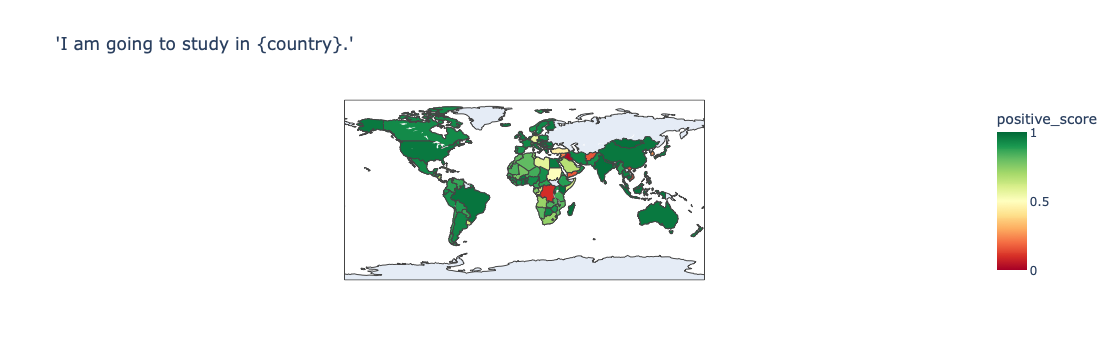

In [20]:
custom_queries = [
    "I am going to work in {country}.",
    "I am going to study in {country}."
]

for query in custom_queries:
    df = run_sentiment_query(query, country_df)
    plot_choropleth(df, f"'{query}'")

# 4) Use of causal language model: GPT-2 perplexity
Task: To run a sentence through GPT-2, measure how surprised it was, and return the **perplexity** number

In [22]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import torch

tokenizer and model load -->

In [23]:
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
lm_model = GPT2LMHeadModel.from_pretrained("gpt2")
#lm_model.eval()

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [24]:
def compute_perplexity(sentence):
    inputs = tokenizer(sentence, return_tensors="pt")
    # don't track the gradient, model is only for using, not for training
    with torch.no_grad():
        loss = lm_model(**inputs, labels=inputs["input_ids"]).loss
        # ** unpacks the dict
    return torch.exp(loss).item()
    # converts the loss to perplexity

Task: To run **perplexity over all countries**, capping **outliers** for better visualization

input: sentences, list of countries -->

In [29]:
def run_perplexity_query(query, country_df):
    results = []
    for _, row in country_df.iterrows():
        sentence = query.replace("{country}", row["country"])
        ppl = compute_perplexity(sentence)
        results.append({
            "country": row["country"],
            "iso_alpha": row["iso_alpha"],
            "perplexity": ppl
        })
    df = pd.DataFrame(results)
    df["perplexity_capped"] = df["perplexity"].clip(upper=df["perplexity"].quantile(0.95))
    return df

In [30]:
def plot_perplexity(df, title):
    fig = px.choropleth(
        df,
        locations="iso_alpha",
        color="perplexity_capped",
        hover_name="country",
        hover_data=["perplexity"],
        color_continuous_scale="Blues_r",
        title=title
    )
    fig.show()

**high** perplexity = surprising/unusual (darker)

**low** perplexity = natural/expected (lighter)

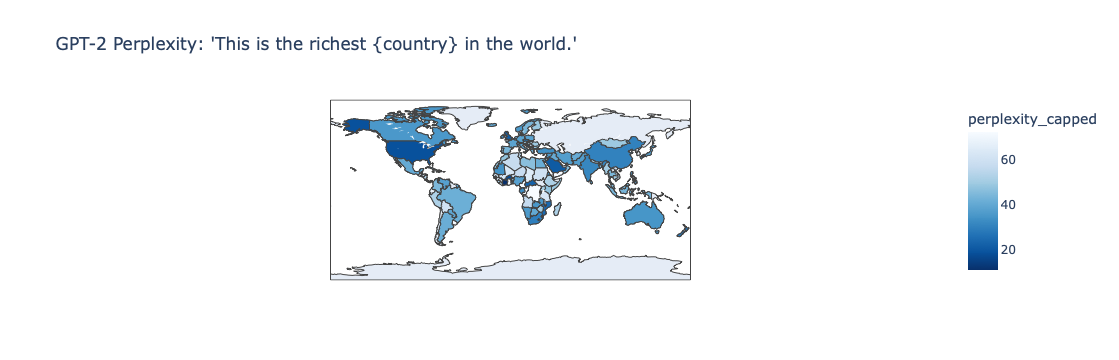

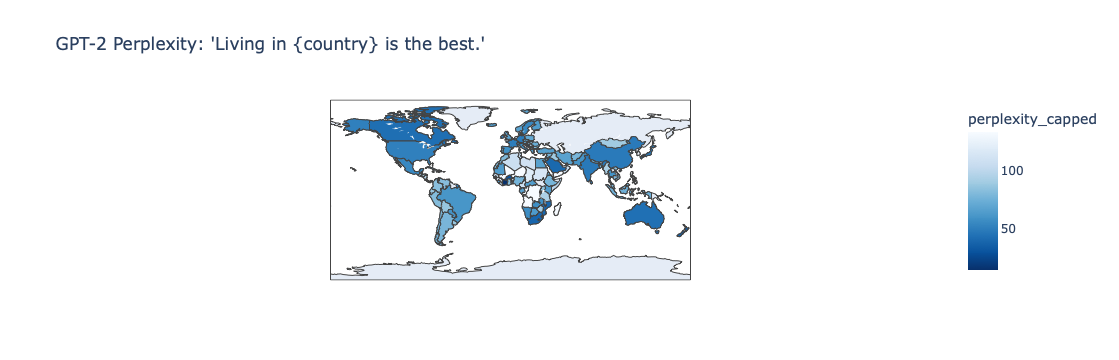

In [31]:
vg_queries = [
    "This is the richest {country} in the world.",
    "Living in {country} is the best."
]

for query in vg_queries:
    df_ppl = run_perplexity_query(query, country_df)
    plot_perplexity(df_ppl, f"GPT-2 Perplexity: '{query}'")

# 5) Analysis of the results

1) In-domain experiment
 
Most sentences were classified correctly with high confidence. However, two results stand out. "Overall, the movie is good, but not my cup of tea." was labelled POSITIVE (1.00) despite containing a negative opinion; the model likely latched onto *good* and ignored the negative implication of *not my cup of tea*, or just simply could not understand the saying. Similarly, "There might never be a better story than this." was labelled NEGATIVE (1.00) despite being a compliment, showing the model struggles with indirect or ambiguous phrasing. The experiment using actors' names shows that confidence drops, suggesting the model has absorbed associations with specific actor names from its training data - or alternatively, that it simply lacks enough context to make a confident prediction.

2) Out-of-domain experiment

The world map shows a clear geographic pattern. Western European countries score 
highly positive (France, Germany, Denmark) while countries associated with conflict 
score very negative (Afghanistan 0.08, Iraq 0.01). The sentence is 
semantically neutral, so this variation is entirely driven by bias in the SST-2 
training data. 

3) Custom queries

For this part, two semantically neutral sentence templates were chosen to test whether the bias pattern persists beyond movie-related phrasing. "I am going to work in {country}" and "I am going to study in {country}" produce 
nearly identical geographic patterns to Part 2, with the same Western-positive and 
conflict-negative split. The consistent pattern across all three templates confirms the bias is driven by 
country name alone, not the sentence structure.

4) GPT-2 perplexity

For this purpose, more provocative statements have been chosen in order to better expose the model's perplexity. For "This is the richest {country} in the world", GPT-2 shows the lowest perplexity for Côte d'Ivoire; a result that appeared consistently across other similar sentences tested prior to settling on the final two templates. This may be attributed to a tokenization issue, as the apostrophe and accent in "Côte d'Ivoire" could cause it to be tokenized differently from other country names.